### 5. Relations between personal background and end marks ###

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Colors as (R, G, B) tuples, same as in "01-Participants-Background"
ColorPrimary = (220,120,0)
ColorSecondary = (0,180,220)

# Hex versions for matplotlib/seaborn, derived from the tuples above
color_primary = '#%02X%02X%02X' % ColorPrimary
color_secondary = '#%02X%02X%02X' % ColorSecondary

# Load the pandas dataframes containing the marks data.
# allDataDF was created in "01-Participants-Background",
# filteredDataDF in "02-End-Marks" (Save Data button in 4-1).
notebook_data_path = Path("../data/notebookData")
allDataDF = pd.read_parquet(notebook_data_path / "allDataDF.parquet")
filteredDataDF = pd.read_parquet(notebook_data_path / "filteredDataDF.parquet")

#### 5.1 Musical experience vs. number of marks ####


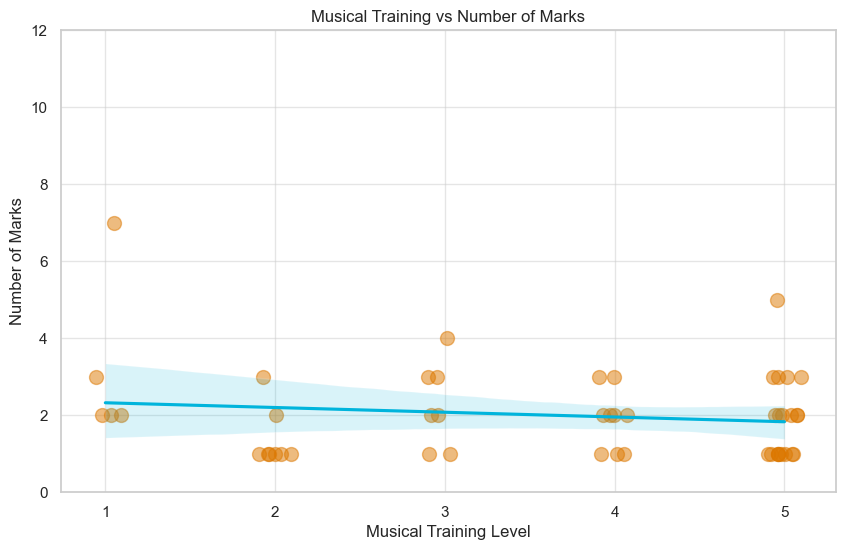

Pearson correlation between musical training and number of marks: -0.147
There is a weak or no linear correlation.


In [7]:

# Prepare the data
# We'll use filteredDataDF as it's the currently active dataset in the notebook
# Filter for timestamps >= 10000 as requested
threshold = 10000
marks_per_user = filteredDataDF[filteredDataDF['timeStamp'] >= threshold].groupby('userID').agg({
    'musicaltraining': 'first',
    'timeStamp': 'count'
}).rename(columns={'timeStamp': 'marks_count'}).reset_index()

#source_marks = ColumnDataSource(marks_per_user)

# Create the figure with Seaborn
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Use regplot to show the scatter points with a regression line (optional)
# or just scatterplot for the raw points.
sns.regplot(
    data=marks_per_user,
    x='musicaltraining',
    y='marks_count',
    x_jitter=0.1, # Adds horizontal jitter to see overlapping points
    scatter_kws={'alpha': 0.5, 's': 100, 'color': color_primary},
    line_kws={'color': color_secondary}
)

# Formatting
plt.title("Musical Training vs Number of Marks", fontsize=12, fontweight='normal')
plt.xlabel("Musical Training Level")
plt.ylabel("Number of Marks")
plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0, marks_per_user['marks_count'].max() + 5)

plt.show()

# Calculate correlation
correlation = marks_per_user['musicaltraining'].corr(marks_per_user['marks_count'])
print(f"Pearson correlation between musical training and number of marks: {correlation:.3f}")

if abs(correlation) < 0.3:
    print("There is a weak or no linear correlation.")
elif abs(correlation) < 0.5:
    print("There is a moderate linear correlation.")
else:
    print("There is a strong linear correlation.")

#### 5.2 Musical experience vs. timecode of first mark ####

In [8]:
import plotly.figure_factory as ff
import plotly.io as pio

# Prepare the data
# Use the threshold of 10000 at the beginning
threshold = 10000

# Get the first mark for each user above the threshold
first_marks_exp = allDataDF[allDataDF['timeStamp'] >= threshold].sort_values('timeStamp').groupby('userID').first().reset_index()

# Group 1: musicaltraining is 1, 2, or 3
group_low_training = first_marks_exp[first_marks_exp['musicaltraining'] <= 3].copy()

# Group 2: musicaltraining is 4 or 5
group_high_training = first_marks_exp[first_marks_exp['musicaltraining'] >= 4].copy()

# Quick check of the counts
print(f"All first marks: {len(first_marks_exp)}")
print(f"Group 1 (Low Training) size: {len(group_low_training)}")
print(f"Group 2 (High Training) size: {len(group_high_training)}")

# 1. Extract the timestamp values from your groups
hist_data = [
    group_low_training['timeStamp'].tolist(),
    group_high_training['timeStamp'].tolist()
]

# 2. Define labels for the legend
group_labels = ['Low Training (1-3)', 'High Training (4-5)']

# 3. Create the distplot

# Set the renderer to 'notebook_connected' to maintain interactivity in PyCharm
# without requiring the 'nbformat' library.
pio.renderers.default = "notebook_connected"

# bin_size is set to 10000ms (10s) to keep it readable, but adjust as needed
fig = ff.create_distplot(
    hist_data,
    group_labels,
    bin_size=10000,
    show_hist=True,  # Shows the bars
    show_curve=True, # Shows the KDE line
    show_rug=True    # Shows the individual marks at the bottom
)

# 4. Add styling to match the context of your experiment
fig.update_layout(
    title_text='Density of First Marks by Musical Training Level',
    xaxis_title='Time (ms)',
    yaxis_title='Density',
    template='plotly_white',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.3, # Adjust this value if the legend overlaps the x-axis label
        xanchor="center",
        x=0.5
    )
)

fig.show()

'''
# Calculate correlation
correlation_first = first_marks_exp['musicaltraining'].corr(first_marks_exp['timeStamp'])
print(f"Pearson correlation between musical training and timecode of first mark: {correlation_first:.3f}")

if abs(correlation_first) < 0.3:
    print("There is a weak or no linear correlation.")
elif abs(correlation_first) < 0.5:
    print("There is a moderate linear correlation.")
else:
    print("There is a strong linear correlation.")
'''


All first marks: 49
Group 1 (Low Training) size: 20
Group 2 (High Training) size: 29


'\n# Calculate correlation\ncorrelation_first = first_marks_exp[\'musicaltraining\'].corr(first_marks_exp[\'timeStamp\'])\nprint(f"Pearson correlation between musical training and timecode of first mark: {correlation_first:.3f}")\n\nif abs(correlation_first) < 0.3:\n    print("There is a weak or no linear correlation.")\nelif abs(correlation_first) < 0.5:\n    print("There is a moderate linear correlation.")\nelse:\n    print("There is a strong linear correlation.")\n'

#### 5.3 Improvisation experience vs. timecode of first mark ####

In [9]:
# Use the threshold of 10000 at the beginning (same as in 5.2)
threshold = 10000

# Get the first mark for each user above the threshold
first_marks_impro = allDataDF[allDataDF['timeStamp'] >= threshold].sort_values('timeStamp').groupby('userID').first().reset_index()

# Group 1: experienceimprovising is 1, 2, or 3
group_low_experience = first_marks_impro[first_marks_impro['experienceimprovising'] <= 3].copy()

# Group 2: experienceimprovising is 4 or 5
group_high_experience = first_marks_impro[first_marks_impro['experienceimprovising'] >= 4].copy()

# Quick check of the counts
print(f"All first marks: {len(first_marks_impro)}")
print(f"Group 1 (Low Improvisation Experience) size: {len(group_low_experience)}")
print(f"Group 2 (High Improvisation Experience) size: {len(group_high_experience)}")

# 1. Extract the timestamp values from your groups
hist_data = [
    group_low_experience['timeStamp'].tolist(),
    group_high_experience['timeStamp'].tolist()
]

# 2. Define labels for the legend
group_labels = ['Low Improvisation Experience (1-3)', 'High Improvisation Experience (4-5)']

# 3. Create the distplot

# Set the renderer to 'notebook_connected' to maintain interactivity in PyCharm
# without requiring the 'nbformat' library.
pio.renderers.default = "notebook_connected"

# bin_size is set to 10000ms (10s) to keep it readable, but adjust as needed
fig = ff.create_distplot(
    hist_data,
    group_labels,
    bin_size=10000,
    show_hist=True,  # Shows the bars
    show_curve=True, # Shows the KDE line
    show_rug=True    # Shows the individual marks at the bottom
)

# 4. Add styling to match the context of your experiment
fig.update_layout(
    title_text='Density of First Marks by Improvisation Experience Level',
    xaxis_title='Time (ms)',
    yaxis_title='Density',
    template='plotly_white',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.3, # Adjust this value if the legend overlaps the x-axis label
        xanchor="center",
        x=0.5
    )
)

fig.show()

'''
# Calculate correlation
correlation_impro = first_marks_impro['experienceimprovising'].corr(first_marks_impro['timeStamp'])
print(f"Pearson correlation between improvisation experience and timecode of first mark: {correlation_impro:.3f}")

if abs(correlation_impro) < 0.3:
    print("There is a weak or no linear correlation.")
elif abs(correlation_impro) < 0.5:
    print("There is a moderate linear correlation.")
else:
    print("There is a strong linear correlation.")
    '''

All first marks: 49
Group 1 (Low Improvisation Experience) size: 32
Group 2 (High Improvisation Experience) size: 17


'\n# Calculate correlation\ncorrelation_impro = first_marks_impro[\'experienceimprovising\'].corr(first_marks_impro[\'timeStamp\'])\nprint(f"Pearson correlation between improvisation experience and timecode of first mark: {correlation_impro:.3f}")\n\nif abs(correlation_impro) < 0.3:\n    print("There is a weak or no linear correlation.")\nelif abs(correlation_impro) < 0.5:\n    print("There is a moderate linear correlation.")\nelse:\n    print("There is a strong linear correlation.")\n    '